# AEDT open project example

This example shows how to use the ``AEDTCommon`` class to
launch a new AEDT session in a thread and
open an existing AEDT project.

## Perform required imports

Perform the required imports.

In [1]:
import sys
import os
import shutil

In [2]:
from ansys.aedt.core import generate_unique_folder_name

In [3]:
from ansys.aedt.toolkits.common.utils import download_file
from ansys.aedt.toolkits.common.backend.api import AEDTCommon

## Initialize temporary folder and project settings

Initialize a temporary folder to copy the input file into
and specify project settings.

In [4]:
URL_BASE = "https://raw.githubusercontent.com/ansys/example-data/master/toolkits/common/"
AEDT_PROJECT = "Test.aedt"
URL = os.path.join(URL_BASE, AEDT_PROJECT)

temp_folder = os.path.join(generate_unique_folder_name())

local_project = os.path.join(temp_folder, AEDT_PROJECT)

download_file(URL, local_project)

'C:\\Users\\ansys\\AppData\\Local\\Temp\\pyaedt_prj_OS6\\Test.aedt'

## Initialize toolkit

Initialize the toolkit.

In [5]:
toolkit = AEDTCommon()

## Initialize AEDT

Launch a new AEDT session in a thread.

In [6]:
thread_msg = toolkit.launch_thread(toolkit.launch_aedt)

## Wait for the toolkit thread to be idle

Wait for the toolkit thread to be idle and ready to accept a new task.

In [7]:
idle = toolkit.wait_to_be_idle()
if not idle:
    print("AEDT not initialized.")
    sys.exit()

INFO - AEDT is released.


## Open project

Open the project.

In [8]:
open_msg = toolkit.open_project(local_project)

INFO - Updating internal properties.


INFO - AEDT is released.


## Get toolkit properties

Get the toolkit properties, which contain the project information.

In [9]:
new_properties = toolkit.get_properties()

## Connect design

Connect or create a new design.

In [10]:
toolkit.connect_design()

INFO - Updating internal properties.


INFO - Toolkit is connected to AEDT design.


True

## Create a box

Create a box in the design.

INFO - Create Box


C:\actions-runner\_work\pyaedt-toolkits-common\pyaedt-toolkits-common\.venv\Lib\site-packages\ansys\aedt\core\visualization\plot\pyvista.py:1402: UserWarning: Failed to use notebook backend: 

Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from pyvista.trame.jupyter import launch_server
await launch_server().ready

Falling back to a static output.
  self.pv.show(auto_close=False, jupyter_backend=self.jupyter_backend)  # pragma: no cover


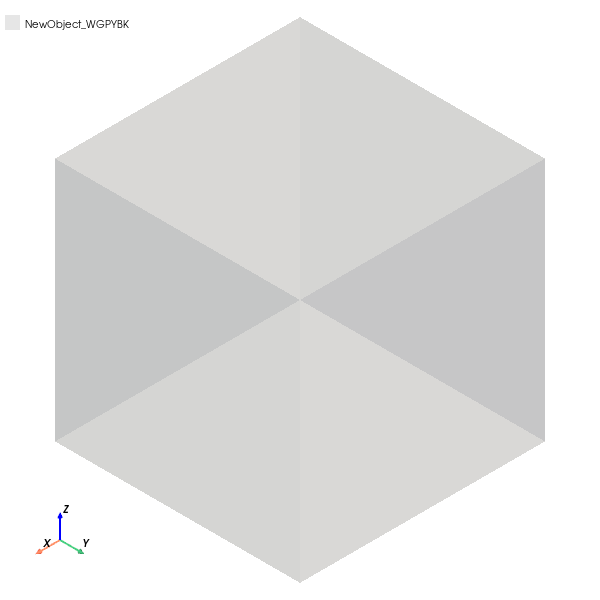

In [11]:
toolkit.logger.info("Create Box")
box = toolkit.aedtapp.modeler.create_box([10, 10, 10], [20, 20, 20])
model = toolkit.aedtapp.plot(show=True)

## Save and release AEDT

Save and release AEDT.

In [12]:
toolkit.release_aedt(True, True)

INFO - AEDT is released.


True

## Remove temporary folder

Remove the temporary folder.

In [13]:
shutil.rmtree(temp_folder, ignore_errors=True)